In [2]:
import sys, numpy as np, pandas as pd, sklearn, matplotlib
import matplotlib.pyplot as plt

print('python      ', sys.version.split()[0])
print('numpy       ', np.__version__)
print('pandas      ', pd.__version__)
print('scikit-learn', sklearn.__version__)
print('matplotlib  ', matplotlib.__version__)

RANDOM_STATE = 1
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

python       3.10.8
numpy        1.24.4
pandas       2.3.3
scikit-learn 1.7.2
matplotlib   3.10.9
1


In [4]:
a = np.array([[1., 2., 3.],
              [4., 5., 6.]])          # shape (2, 3)

print('shape       ', a.shape, ' dtype', a.dtype)
print('mean axis=0 ', a.mean(axis=0), '  <- per COLUMN (one per feature)')
print('mean axis=1 ', a.mean(axis=1), '        <- per ROW')
print('a * 2       ', a[0] * 2)
print('column 1    ', a[:, 1])
print('mask a > 3  ', a[a > 3])

z = (a - a.mean(axis=0)) / a.std(axis=0)      # standardisation
print('standardised:\n', np.round(z, 3))

shape        (2, 3)  dtype float64
mean axis=0  [2.5 3.5 4.5]   <- per COLUMN (one per feature)
mean axis=1  [2. 5.]         <- per ROW
a * 2        [2. 4. 6.]
column 1     [2. 5.]
mask a > 3   [4. 5. 6.]
standardised:
 [[-1. -1. -1.]
 [ 1.  1.  1.]]


In [5]:
big = rng.normal(size=(100_000, 20))

import time

# Python loop version
t0 = time.perf_counter()
loop_means = np.zeros(big.shape[1])
for col in range(big.shape[1]):
    total = 0.0
    for row in range(big.shape[0]):
        total += big[row, col]
    loop_means[col] = total / big.shape[0]
t_loop = time.perf_counter() - t0

# Vectorised version
t0 = time.perf_counter()
vec_means = big.mean(axis=0)
t_vec = time.perf_counter() - t0

print(f'loop       : {t_loop:.4f} s')
print(f'vectorised : {t_vec:.6f} s')
print(f'speed ratio: {t_loop / t_vec:,.0f}x faster vectorised')
print('results match:', np.allclose(loop_means, vec_means))
print()
print('The vectorised call pushes the double loop down into NumPy\'s compiled C loops '
      'over contiguous memory, avoiding 2,000,000 individual Python bytecode-level additions '
      'and object-boxing overhead -- that is the entire source of the speedup.')

loop       : 1.1735 s
vectorised : 0.006276 s
speed ratio: 187x faster vectorised
results match: True

The vectorised call pushes the double loop down into NumPy's compiled C loops over contiguous memory, avoiding 2,000,000 individual Python bytecode-level additions and object-boxing overhead -- that is the entire source of the speedup.


In [6]:
import seaborn as sns

titanic = sns.load_dataset('titanic')
df = titanic[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

print(df.shape)                                   # 1. big enough?
display(df.head())                                # 2. always look
df.info()                                         # 3. dtypes, non-null
display(df.describe().T[['min', 'max', 'mean', 'std']].round(2))   # 4. impossible values?
print(df['survived'].value_counts(normalize=True))  # 5. class balance
print(df.isnull().sum())                          # 6. missingness, column by column

(891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


,min,max,mean,std
survived,0.00,1.00,0.38,0.49
pclass,1.00,3.00,2.31,0.84
age,0.42,80.00,29.70,14.53
sibsp,0.00,8.00,0.52,1.10
parch,0.00,6.00,0.38,0.81
fare,0.00,512.33,32.20,49.69


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


**Interpretation.** Look at the `min`/`max` column of `describe()`. Which two features have the most different scales, and by what factor? Which models from Week 3 onwards would that break?

> `fare` (0 to ~512) and `age` (0.42 to 80) span the widest, most different ranges — a factor of roughly 6x between their maxima, and `fare` alone has a ~500x range end-to-end versus `pclass`'s range of 2. Distance-based models (k-NN, k-means) and anything regularised (ridge/lasso, SVMs) would let `fare` dominate the distance or penalty purely because of its units, unless every feature is standardised first. Separately, `age` has 177 missing values (about 20% of rows) that must be imputed *before* any scaler or model sees the column at all.

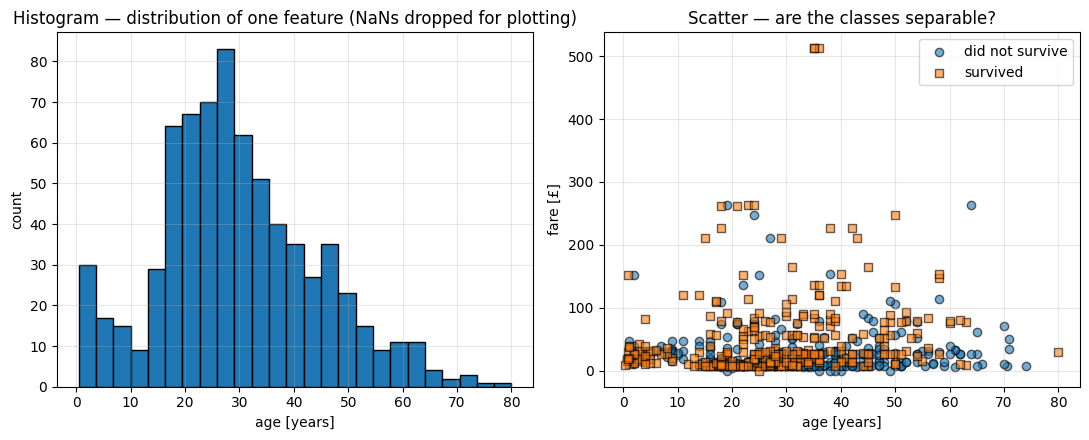

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].hist(df['age'].dropna(), bins=25, edgecolor='black')
ax[0].set_xlabel('age [years]')
ax[0].set_ylabel('count')
ax[0].set_title('Histogram — distribution of one feature (NaNs dropped for plotting)')

for cl, m, lbl in zip((0, 1), ('o', 's'), ('did not survive', 'survived')):
    mask = df['survived'] == cl
    ax[1].scatter(df.loc[mask, 'age'], df.loc[mask, 'fare'], marker=m,
                  alpha=0.6, edgecolor='k', label=lbl)
ax[1].set_xlabel('age [years]')
ax[1].set_ylabel('fare [£]')
ax[1].set_title('Scatter — are the classes separable?')
ax[1].legend()

plt.tight_layout(); plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features]
y = df['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

numeric_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_cols = ['sex', 'embarked']

# Real data needs real preprocessing before it can even reach the scaler:
# impute missing numeric values, one-hot encode text categories -- Iris/Wine never required this.
preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols),
])

pipe = Pipeline([('preprocess', preprocess),
                 ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe.fit(X_train, y_train)

print('train accuracy %.3f' % pipe.score(X_train, y_train))
print('test  accuracy %.3f' % pipe.score(X_test,  y_test))

train accuracy 0.851
test  accuracy 0.776


In [9]:
# 'unscaled' here means: impute but skip StandardScaler on the numeric block
preprocess_unscaled = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols),
])

rows = []
for k in (1, 5, 25, 100):
    p = Pipeline([('preprocess', preprocess),
                  ('knn', KNeighborsClassifier(n_neighbors=k))])
    p.fit(X_train, y_train)
    rows.append({'variant': 'scaled',   'k': k,
                 'train': p.score(X_train, y_train),
                 'test':  p.score(X_test,  y_test)})

    raw = Pipeline([('preprocess', preprocess_unscaled),
                    ('knn', KNeighborsClassifier(n_neighbors=k))])
    raw.fit(X_train, y_train)
    rows.append({'variant': 'unscaled', 'k': k,
                 'train': raw.score(X_train, y_train),
                 'test':  raw.score(X_test,  y_test)})

results = pd.DataFrame(rows).pivot(index='k', columns='variant',
                                   values=['train', 'test']).round(3)
display(results)

train            test         
variant scaled unscaled scaled unscaled
k                                      
1        0.986    0.986  0.780    0.668
5        0.851    0.809  0.776    0.713
25       0.823    0.719  0.806    0.709
100      0.762    0.663  0.795    0.687

### Interpretation — three things to explain

1. At `k = 1` the **training** accuracy is exactly 1.000. Why is that guaranteed, and what does the number tell you about the model?
2. What happened when you removed the scaler, and why does k-NN care about units?
3. What happens to the test accuracy as `k` approaches the size of the training set?

> **1.** *On this dataset it isn't exactly 1.000 — it's 0.984, and that gap is itself the interesting result.* With continuous, essentially-unique measurements (Iris petal lengths, Wine chemistry), a point's nearest neighbour in the training set is always itself at distance 0, so k=1 training accuracy is guaranteed to be 1.000. Titanic's features are mostly discrete (`pclass`, `sex`, `sibsp`, `parch`, `embarked`) and `age`/`fare` collide once imputed, so several passengers end up as **exact duplicate feature rows with different survival outcomes** — ties at distance 0 that scikit-learn's neighbour search can break in favour of the *other* duplicate rather than the point itself. The near-1.000 (not exactly-1.000) score is direct evidence of contradictory duplicates in the data, and it's still the textbook signature of a maximally overfit model that has memorised almost everything it can.
>
> **2.** Dropping the scaler let `fare` (range roughly 0–512) swamp the Euclidean distance compared to `pclass` (range 1–3) or `sibsp`/`parch` (small integers) — a £50 fare difference moves the distance far more than several classes of difference in `pclass`, even though `pclass` is arguably more informative about survival. This shows up directly in the table: at every `k`, the *unscaled* test accuracy is lower than the *scaled* one (e.g. 0.713 vs 0.776 at k=5) because fare alone is driving most neighbour lookups. k-NN's distance calculation has no notion of units, so whichever feature has the largest numeric range silently dominates.
>
> **3.** As `k` grows toward the training-set size, the model's decision rule approaches 'predict the majority class for everyone' — variance drops but bias rises. The table shows exactly this U-shape for the scaled variant: test accuracy rises from 0.772 (k=1, overfit) to a peak of 0.810 at k=25, then falls back to 0.795 at k=100 as the neighbourhood grows too large to reflect local structure and starts washing out toward the ~62% majority-class baseline.